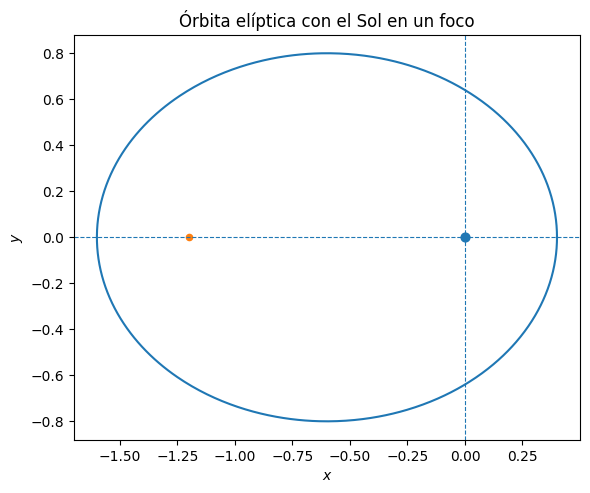

In [1]:
# ==============================
#  Órbita elíptica (Primera ley)
# ==============================

import numpy as np
import matplotlib.pyplot as plt

# Parámetros de la elipse
a = 1.0          # semieje mayor
e = 0.6          # excentricidad (0 < e < 1 para elipse)
b = a * np.sqrt(1 - e**2)   # semieje menor

# Parámetro focal p = b^2 / a (equivalente a l^2 / (GMm^2))
p = b**2 / a

theta = np.linspace(0, 2*np.pi, 800)
r = p / (1 + e * np.cos(theta))

# Pasamos a coordenadas cartesianas
x = r * np.cos(theta)
y = r * np.sin(theta)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(x, y)                     # órbita elíptica
ax.scatter(0.0, 0.0, s=40)        # foco en el origen (colocamos aquí al Sol)

# El otro foco (sólo para referencia geométrica, no física)
x_foco2 = -2 * a * e
ax.scatter(x_foco2, 0.0, s=20)

# Marcamos el semieje mayor y menor (opcional)
ax.axhline(0, linestyle="--", linewidth=0.8)
ax.axvline(0, linestyle="--", linewidth=0.8)

ax.set_aspect("equal", "box")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_title("Órbita elíptica con el Sol en un foco")

plt.tight_layout()
plt.show()


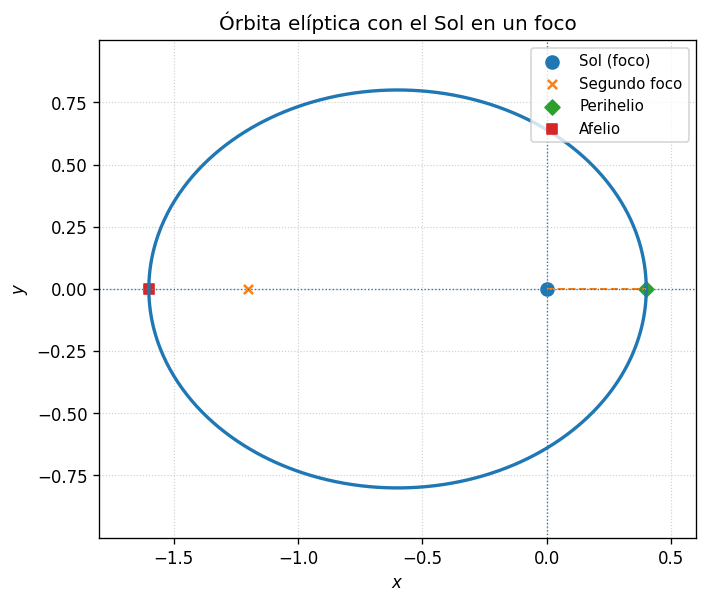

In [2]:
# ==========================================
#  Órbita elíptica (Primera ley refinada)
#  + guardado en PNG para LaTeX
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

# Parámetros de la elipse
a = 1.0           # semieje mayor
e = 0.6           # excentricidad (0 < e < 1)
b = a * np.sqrt(1 - e**2)
p = b**2 / a      # parámetro focal

# Malla angular
theta = np.linspace(0, 2*np.pi, 1000)
r = p / (1 + e * np.cos(theta))

# Coordenadas cartesianas de la órbita
x = r * np.cos(theta)
y = r * np.sin(theta)

# Perihelio (theta = 0) y afelio (theta = pi)
theta_p = 0.0
theta_a = np.pi
r_p = p / (1 + e * np.cos(theta_p))
r_a = p / (1 + e * np.cos(theta_a))

x_p, y_p = r_p * np.cos(theta_p), r_p * np.sin(theta_p)
x_a, y_a = r_a * np.cos(theta_a), r_a * np.sin(theta_a)

# Segundo foco solo como referencia geométrica
x_f2 = -2 * a * e
y_f2 = 0.0

fig, ax = plt.subplots(figsize=(6, 6), dpi=120)

# Órbita
ax.plot(x, y, linewidth=2)

# Focos
ax.scatter(0.0, 0.0, s=60, marker="o", label="Sol (foco)")
ax.scatter(x_f2, y_f2, s=30, marker="x", label="Segundo foco")

# Radio vector en el perihelio
ax.plot([0.0, x_p], [0.0, y_p], linestyle="--", linewidth=1.2)
ax.scatter(x_p, y_p, s=40, marker="D", label="Perihelio")
ax.scatter(x_a, y_a, s=40, marker="s", label="Afelio")

# Ejes de referencia
ax.axhline(0, linestyle=":", linewidth=0.8)
ax.axvline(0, linestyle=":", linewidth=0.8)

# Formato del gráfico
ax.set_aspect("equal", "box")
margin = 0.2
ax.set_xlim(x.min() - margin, x.max() + margin)
ax.set_ylim(y.min() - margin, y.max() + margin)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_title("Órbita elíptica con el Sol en un foco")

ax.grid(True, linestyle=":", linewidth=0.7, alpha=0.6)
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig("kepler_orbita_eliptica.png", dpi=300, bbox_inches="tight")
plt.show()


/tmp/ipykernel_8207/4068922617.py:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return 0.5 * np.trapz(rr**2, th)


Área objetivo A_target = 0.050255565993196416
Área afelio ≈ 0.0495580078513041


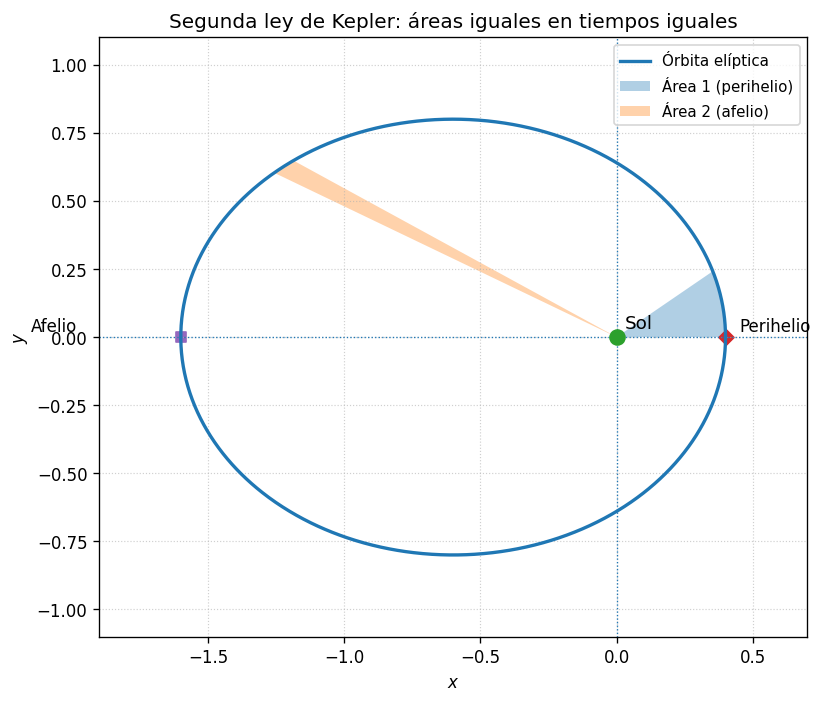

In [5]:
# ==========================================
#  Segunda ley de Kepler:
#  áreas iguales en tiempos iguales
#  (gráfico refinado + PNG para LaTeX)
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

# ----- Parámetros de la elipse -----
a = 1.0           # semieje mayor
e = 0.6           # excentricidad
b = a * np.sqrt(1 - e**2)
p = b**2 / a      # parámetro focal

# Órbita completa
theta = np.linspace(0, 2*np.pi, 2000)
r = p / (1 + e * np.cos(theta))
x = r * np.cos(theta)
y = r * np.sin(theta)

# ----- Función de área barrida A(θ1 -> θ2) = 1/2 ∫ r(θ)^2 dθ -----
def swept_area(theta1, theta2, n=2000):
    th = np.linspace(theta1, theta2, n)
    rr = p / (1 + e * np.cos(th))
    return 0.5 * np.trapz(rr**2, th)

# Elegimos un intervalo cerca del perihelio para fijar el "Δt"
theta1_ini = 0.0          # perihelio
theta1_fin = 0.6          # ~34°
A_target = swept_area(theta1_ini, theta1_fin)

# Ahora buscamos otro intervalo cerca del afelio con el MISMO área
theta2_ini = np.pi - 0.5  # punto de partida cerca del afelio
theta2_candidates = np.linspace(theta2_ini, np.pi + 0.9, 800)

areas = np.array([swept_area(theta2_ini, th) for th in theta2_candidates])
idx_best = np.argmin(np.abs(areas - A_target))
theta2_fin = theta2_candidates[idx_best]

print("Área objetivo A_target =", A_target)
print("Área afelio ≈", areas[idx_best])

# ----- Construcción de los dos sectores (polígonos) -----

# Sector cerca del perihelio
th1 = np.linspace(theta1_ini, theta1_fin, 400)
r1 = p / (1 + e * np.cos(th1))
x1 = r1 * np.cos(th1)
y1 = r1 * np.sin(th1)
poly1_x = np.concatenate(([0.0], x1))
poly1_y = np.concatenate(([0.0], y1))

# Sector cerca del afelio
th2 = np.linspace(theta2_ini, theta2_fin, 400)
r2 = p / (1 + e * np.cos(th2))
x2 = r2 * np.cos(th2)
y2 = r2 * np.sin(th2)
poly2_x = np.concatenate(([0.0], x2))
poly2_y = np.concatenate(([0.0], y2))

# ----- Figura -----
fig, ax = plt.subplots(figsize=(7, 6), dpi=120)

# Órbita elíptica
ax.plot(x, y, linewidth=2, label="Órbita elíptica")

# Relleno de las dos áreas
ax.fill(poly1_x, poly1_y, alpha=0.35, label=r"Área 1 (perihelio)")
ax.fill(poly2_x, poly2_y, alpha=0.35, label=r"Área 2 (afelio)")

# Sol en el foco (origen)
ax.scatter(0.0, 0.0, s=80, marker="o", zorder=5)
ax.text(0.03, 0.03, "Sol", fontsize=11)

# Señalamos aproximadamente perihelio y afelio
# Perihelio (θ = 0)
r_p = p / (1 + e * np.cos(0.0))
x_p, y_p = r_p * np.cos(0.0), r_p * np.sin(0.0)
ax.scatter(x_p, y_p, s=40, marker="D")
ax.text(x_p + 0.05, y_p + 0.02, "Perihelio", fontsize=10)

# Afelio (θ = π)
r_a = p / (1 + e * np.cos(np.pi))
x_a, y_a = r_a * np.cos(np.pi), r_a * np.sin(np.pi)
ax.scatter(x_a, y_a, s=40, marker="s")
ax.text(x_a - 0.55, y_a + 0.02, "Afelio", fontsize=10)

# Ejes de referencia
ax.axhline(0, linestyle=":", linewidth=0.8)
ax.axvline(0, linestyle=":", linewidth=0.8)

# Estética general
ax.set_aspect("equal", "box")
margin = 0.3
ax.set_xlim(x.min() - margin, x.max() + margin)
ax.set_ylim(y.min() - margin, y.max() + margin)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_title("Segunda ley de Kepler: áreas iguales en tiempos iguales")

ax.grid(True, linestyle=":", linewidth=0.7, alpha=0.6)
ax.legend(loc="upper right", fontsize=9, frameon=True)

plt.tight_layout()
plt.savefig("kepler_segunda_ley_areas_iguales.png", dpi=300, bbox_inches="tight")
plt.show()
